In [1]:
from pathlib import Path

import pandas as pd
from pandas import DataFrame

from caveat.evaluate.describe.frequency import frequency_plots
from caveat.evaluate.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from caveat.evaluate.describe.transitions import sequence_prob_plot

In [2]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}

batch_paths = {
    "DiscFF": Path("../logs/vae_paper/DiscFF"),
    "DiscCNN": Path("../logs/vae_paper/DiscCNN"),
    "DiscRNN": Path("../logs/vae_paper/DiscRNN"),
    "ContFF": Path("../logs/vae_paper/ContFF"),
    "ContCNN": Path("../logs/vae_paper/ContCNN"),
    "ContRNN": Path("../logs/vae_paper/ContRNN"),
}
target_schedules = pd.read_csv("../tmp/nts_schedules_2023.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}

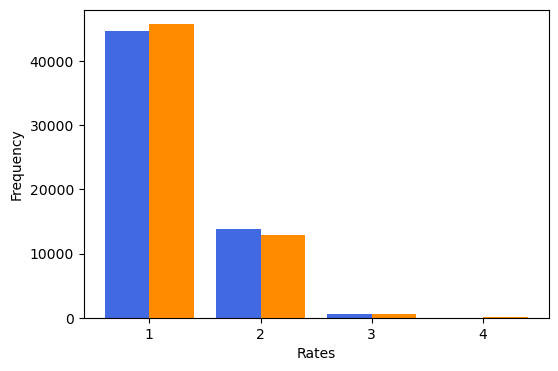

In [3]:
import matplotlib.pyplot as plt
import numpy as np

from caveat.evaluate.features.participation import participation_rates_by_act

act = "work"
width = 0.4

x = np.arange(4)

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_ylabel("Frequency")
ax.set_xlabel("Rates")

bins_t, freqs_t = participation_rates_by_act(target_schedules)[act]
freqs_t = freqs_t[:4]
ax.bar(x - width / 2, freqs_t, width, label="Real", color="royalblue")

bins, freqs = participation_rates_by_act(schedules["ContRNN"])[act]
freqs = freqs[:4]
ax.bar(x + width / 2, freqs, width, label="Synthetic", color="darkorange")

ax.set_xticks(x, [1, 2, 3, 4])

[0.00694444 0.02083333 0.03472222 0.04861111 0.0625     0.07638889
 0.09027778 0.11805556 0.13194444 0.14583333 0.15972222 0.17361111
 0.1875     0.20138889 0.21527778 0.22916667 0.24305556 0.25694444
 0.27083333 0.28472222 0.29861111 0.3125     0.32638889 0.34027778
 0.35416667 0.36805556 0.38194444 0.39583333 0.40972222 0.42361111
 0.4375     0.45138889 0.46527778 0.47916667 0.49305556 0.50694444
 0.52083333 0.53472222 0.54861111 0.5625     0.57638889 0.59027778
 0.60416667 0.61805556 0.63194444 0.64583333 0.65972222 0.67361111
 0.6875     0.70138889 0.71527778 0.72916667 0.74305556 0.75694444
 0.77083333 0.78472222 0.79861111 0.8125     0.82638889 0.84027778
 0.85416667 0.86805556 0.88194444 0.89583333 0.90972222 0.9375    ]
[0.10416667 0.11805556 0.13194444 0.14583333 0.15972222 0.17361111
 0.1875     0.20138889 0.21527778 0.22916667 0.24305556 0.25694444
 0.27083333 0.28472222 0.29861111 0.3125     0.32638889 0.34027778
 0.35416667 0.36805556 0.38194444 0.39583333 0.40972222 0.423

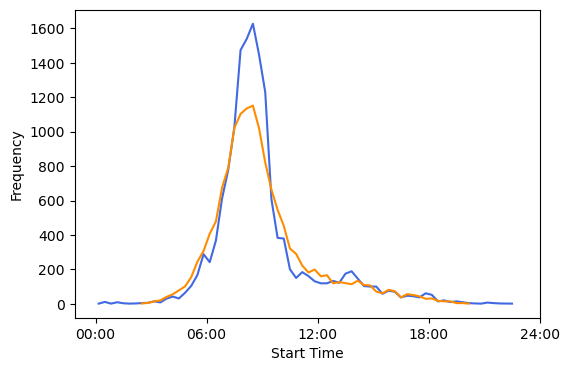

In [4]:
import matplotlib.pyplot as plt
import numpy as np

from caveat.evaluate.features.times import start_times_by_act

act = "work"

fig, ax = plt.subplots(figsize=(6, 4))
ax.set_ylabel("Frequency")
ax.set_xlabel("Start Time")

bins_t, freqs_t = start_times_by_act(target_schedules, bin_size=20)[act]
print(bins_t)
ax.plot(bins_t, freqs_t, width, label="Real", color="royalblue")

bins, freqs = start_times_by_act(schedules["ContRNN"], bin_size=20)[act]
print(bins)
ax.plot(bins, freqs, width, label="Synthetic", color="darkorange")

ax.set_xticks(
    np.arange(0, 1.1, 0.25), ["00:00", "06:00", "12:00", "18:00", "24:00"]
)

In [5]:
def domain_distances(batch_paths, suffix=""):
    distances_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / f"domain_distances{suffix}.csv"
        ).set_index("domain")

        columns = list(
            set(distances.columns) - set(["domain", "observed", "mean", "std"])
        )
        distances_combined[(name, "dist")] = distances[columns].mean(axis=1)
        variances_combined[(name, "std")] = (
            distances[columns].std(axis=1) / distances_combined[(name, "dist")]
        )

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )
    variances_combined.columns = pd.MultiIndex.from_tuples(
        variances_combined.columns
    )

    return distances_combined, variances_combined


domain_dist, domain_std = domain_distances(batch_paths, suffix="")
print(domain_dist[::-1].to_latex(float_format="{:.3f}".format))
display(domain_dist)

\begin{tabular}{lrrrrrr}
\toprule
 & dist & dist & dist & dist & dist & dist \\
domain &  &  &  &  &  &  \\
\midrule
aggregate & 0.005 & 0.006 & 0.017 & 0.014 & 0.012 & 0.009 \\
count & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 & 0.000 \\
creativity & 0.284 & 0.313 & 0.641 & 0.082 & 0.179 & 0.017 \\
participations & 0.152 & 0.162 & 0.817 & 0.062 & 0.046 & 0.064 \\
sample quality & 0.000 & 0.000 & 0.050 & 0.057 & 0.030 & 0.018 \\
timing & 0.051 & 0.044 & 0.210 & 0.056 & 0.055 & 0.025 \\
transitions & 0.008 & 0.006 & 0.165 & 0.004 & 0.005 & 0.004 \\
\bottomrule
\end{tabular}



,DiscFF,DiscCNN,DiscRNN,ContFF,ContCNN,ContRNN
,dist,dist,dist,dist,dist,dist
domain,,,,,,
aggregate,0.005273,0.005886,0.017250,0.013543,0.012246,0.008588
count,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
creativity,0.284242,0.312884,0.641034,0.081955,0.179218,0.017146
participations,0.152095,0.162393,0.817477,0.061814,0.045899,0.063894
sample quality,0.000309,0.000000,0.049654,0.057196,0.030299,0.018193
timing,0.050741,0.043837,0.210128,0.055525,0.054676,0.025205
transitions,0.008437,0.006389,0.164791,0.004049,0.004828,0.003823


In [6]:
def distribution_distances(batch_paths):
    distances_combined = pd.DataFrame()
    descriptions_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(path / "feature_distances.csv").set_index(
            ["domain", "feature"]
        )
        descriptions = pd.read_csv(path / "feature_descriptions.csv").set_index(
            ["domain", "feature"]
        )

        columns = set(distances.columns)
        columns = list(columns - set(["observed", "unit", "mean", "std"]))

        distances_combined[(name, "mean")] = distances[columns].mean(axis=1)
        variances_combined[(name, "std")] = distances[columns].std(axis=1)
        descriptions_combined[(name, "mean")] = descriptions[columns].mean(
            axis=1
        )

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )
    variances_combined.columns = pd.MultiIndex.from_tuples(
        variances_combined.columns
    )
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    # distances_combined[("Observed", "")] = distances["observed"]
    # distances_combined[("unit", "")] = distances["unit"]

    order = list(distances_combined.columns)
    # order.pop(order.index(("Observed", "")))

    index = [
        "creativity",
        "sample quality",
        "aggregate",
        "participations",
        "transitions",
        "timing",
    ]

    return (
        distances_combined.loc[index, order],
        variances_combined,
        descriptions_combined.loc[index, order],
    )


dist_dist, dist_std, dist_desc = distribution_distances(batch_paths)
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))
print(dist_desc.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))
display(dist_dist)
display(dist_desc)

\begin{tabular}{lrrrrrr}
\toprule
 & DiscFF & DiscCNN & DiscRNN & ContFF & ContCNN & ContRNN \\
 & mean & mean & mean & mean & mean & mean \\
feature &  &  &  &  &  &  \\
\midrule
conservatism & 0.100 & 0.118 & 0.351 & 0.011 & 0.010 & 0.012 \\
homogeneity & 0.468 & 0.507 & 0.931 & 0.153 & 0.348 & 0.022 \\
consecutive & 0.000 & 0.000 & 0.000 & 0.028 & 0.025 & 0.018 \\
invalid & 0.000 & 0.000 & 0.050 & 0.057 & 0.030 & 0.018 \\
not home based & 0.000 & 0.000 & 0.050 & 0.032 & 0.005 & 0.001 \\
agg. frequency & 0.005 & 0.006 & 0.017 & 0.014 & 0.012 & 0.009 \\
lengths & 0.363 & 0.399 & 2.100 & 0.140 & 0.100 & 0.154 \\
pair participation rate & 0.014 & 0.011 & 0.052 & 0.005 & 0.005 & 0.004 \\
participation rate & 0.079 & 0.078 & 0.301 & 0.040 & 0.033 & 0.033 \\
2-gram & 0.020 & 0.015 & 0.145 & 0.009 & 0.010 & 0.008 \\
3-gram & 0.004 & 0.003 & 0.136 & 0.002 & 0.003 & 0.002 \\
4-gram & 0.002 & 0.002 & 0.213 & 0.001 & 0.002 & 0.001 \\
durations & 0.039 & 0.034 & 0.215 & 0.041 & 0.039 & 0.016 \\


DiscFF   DiscCNN   DiscRNN  \
                                            mean      mean      mean   
domain         feature                                                 
creativity     conservatism             0.100420  0.118332  0.351013   
               homogeneity              0.468064  0.507436  0.931055   
sample quality consecutive              0.000000  0.000000  0.000000   
               invalid                  0.000309  0.000000  0.049654   
               not home based           0.000309  0.000000  0.049654   
aggregate      agg. frequency           0.005273  0.005886  0.017250   
participations lengths                  0.362578  0.398694  2.099803   
               pair participation rate  0.014246  0.010823  0.051661   
               participation rate       0.079460  0.077663  0.300966   
transitions    2-gram                   0.019597  0.014544  0.145192   
               3-gram                   0.003706  0.002820  0.136490   
               4-gram                   0.002008  0.001803  0.212690   
timing         durations                0.038563  0.033691  0.215332   
               joint-durations          0.069706  0.056699  0.196313   
               start times              0.021509  0.017584  0.028049   
               start-durations          0.073185  0.067376  0.400817   

                                          ContFF   ContCNN   ContRNN  
                                            mean      mean      mean  
domain         feature                                                
creativity     conservatism             0.010808  0.010386  0.012104  
               homogeneity              0.153102  0.348050  0.022188  
sample quality consecutive              0.027561  0.024863  0.017694  
               invalid                  0.057196  0.030299  0.018193  
               not home based           0.032319  0.005495  0.000507  
aggregate      agg. frequency           0.013543  0.012246  0.008588  
participations lengths                  0.140440  0.100289  0.154408  
               pair participation rate  0.005143  0.004733  0.003939  
               participation rate       0.039859  0.032677  0.033335  
transitions    2-gram                   0.009335  0.010018  0.008133  
               3-gram                   0.001627  0.002539  0.001924  
               4-gram                   0.001185  0.001927  0.001412  
timing         durations                0.040600  0.038671  0.016155  
               joint-durations          0.078161  0.075161  0.037689  
               start times              0.032442  0.033016  0.015942  
               start-durations          0.070899  0.071854  0.031032

DiscFF   DiscCNN   DiscRNN  \
                                            mean      mean      mean   
domain         feature                                                 
creativity     diversity                0.531936  0.492564  0.068945   
               novelty                  0.899580  0.881668  0.648987   
sample quality consecutive              0.000000  0.000000  0.000000   
               invalid                  0.000309  0.000000  0.049654   
               not home based           0.000309  0.000000  0.049654   
aggregate      agg. frequency           0.688378  0.684172  0.796730   
participations lengths                  3.811282  3.495574  1.793845   
               pair participation rate  0.044826  0.035591  0.019824   
               participation rate       0.476410  0.436947  0.312911   
transitions    2-gram                   0.057949  0.052225  0.221991   
               3-gram                   0.006945  0.006294  0.217328   
               4-gram                   0.002385  0.002241  0.222487   
timing         durations                0.263062  0.286174  0.568850   
               joint-durations          0.395319  0.447549  0.644236   
               start times              0.428302  0.409472  0.246132   
               start-durations          0.695772  0.700249  0.821657   

                                          ContFF   ContCNN   ContRNN  
                                            mean      mean      mean  
domain         feature                                                
creativity     diversity                0.846898  0.651950  0.977812  
               novelty                  0.989192  0.989614  0.987896  
sample quality consecutive              0.027561  0.024863  0.017694  
               invalid                  0.057196  0.030299  0.018193  
               not home based           0.032319  0.005495  0.000507  
aggregate      agg. frequency           0.619807  0.641150  0.631839  
participations lengths                  3.894383  3.940359  3.840142  
               pair participation rate  0.039647  0.041062  0.039990  
               participation rate       0.486798  0.492545  0.480018  
transitions    2-gram                   0.046746  0.061937  0.048130  
               3-gram                   0.004982  0.009577  0.006278  
               4-gram                   0.002018  0.004292  0.002477  
timing         durations                0.256834  0.253834  0.260462  
               joint-durations          0.429024  0.422315  0.436733  
               start times              0.434009  0.433921  0.429090  
               start-durations          0.692812  0.689691  0.691530

In [7]:
def heads_and_tails(df, n=10):
    # set nan to zero
    df = df.fillna(0)
    df = df.sort_values([("weight", ""), ("Real", "")], ascending=False)
    length = len(df)
    if length < 2 * n:
        return df
    return pd.concat((df.head(n), df.tail(n)))


def get_descriptions(batch_paths):
    combi_desc = pd.DataFrame()
    combi_dist = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions.csv").set_index(
            ["domain", "feature", "segment"]
        )
        distances = pd.read_csv(path / "distances.csv").set_index(
            ["domain", "feature", "segment"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "unit", "mean", "std", "feature count"])
            - weights
        )

        combi_desc[name, "mean"] = descriptions[columns].mean(axis=1)
        combi_dist[name, "mean"] = distances[columns].mean(axis=1)
        # descriptions_combined[name, "var"] = descriptions[columns].var(axis=1)
        # combined[name, "EMD"] = distances[columns].mean(axis=1)

    combi_desc["weight", ""] = distances["observed__weight"]
    combi_desc["Real", ""] = descriptions["observed"]
    combi_desc["unit", ""] = descriptions["unit"]

    combi_dist["weight", ""] = distances["observed__weight"]
    combi_dist["Real", ""] = descriptions["observed"]
    combi_dist["unit", ""] = descriptions["unit"]

    combi_desc.columns = pd.MultiIndex.from_tuples(combi_desc.columns)
    combi_dist.columns = pd.MultiIndex.from_tuples(combi_dist.columns)

    combi_desc = combi_desc.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(heads_and_tails)
    combi_desc = combi_desc.drop(("weight", ""), axis=1)

    combi_dist = combi_dist.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(heads_and_tails)
    combi_dist = combi_dist.drop(("weight", ""), axis=1)

    order = list(combi_desc.columns)
    order.pop(order.index(("Real", "")))
    order = [("Real", "")] + order

    index = [
        "aggregate",
        "participations",
        "transitions",
        "timing",
        "sample quality",
        "creativity",
    ]

    return combi_desc.loc[index, order], combi_dist.loc[index, order]


descriptions, distances = get_descriptions(batch_paths)

/tmp/ipykernel_385274/3495498881.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(0)


In [8]:
display(descriptions.loc["participations", :])

Real    DiscFF   DiscCNN  \
                                                        mean      mean   
feature                 segment                                          
lengths                 sequence lengths  3.893647  3.811282  3.495574   
pair participation rate home+home         1.039079  0.929803  0.913720   
                        other+other       0.086476  0.096249  0.065550   
                        home+other        0.084029  0.092999  0.064571   
                        escort+escort     0.075458  0.038579  0.018959   
                        home+escort       0.072353  0.036507  0.018584   
                        shop+shop         0.033325  0.045055  0.027828   
                        home+shop         0.032701  0.043132  0.027193   
                        visit+visit       0.013397  0.031928  0.015368   
                        home+visit        0.013178  0.030102  0.014687   
                        home+work         0.011221  0.061375  0.026076   
                        shop+visit        0.000000  0.003709  0.001370   
                        shop+medical      0.000000  0.001600  0.000199   
                        shop+escort       0.000000  0.000790  0.000128   
                        visit+medical     0.000000  0.000523  0.000186   
                        visit+escort      0.000000  0.001721  0.000000   
                        medical+escort    0.000000  0.000246  0.000229   
                        education+work    0.000000  0.000128  0.000675   
                        education+other   0.000000  0.000027  0.000000   
                        shop+other        0.000000  0.000449  0.000564   
                        escort+other      0.000000  0.000641  0.000985   
participation rate      home              2.306133  2.142786  2.087617   
                        other             0.523766  0.496401  0.442055   
                        shop              0.291167  0.285420  0.241556   
                        work              0.256425  0.390355  0.294798   
                        escort            0.256070  0.148060  0.106974   
                        visit             0.127647  0.176512  0.156868   
                        education         0.089581  0.127060  0.113511   
                        medical           0.042858  0.044687  0.052196   

                                           DiscRNN    ContFF   ContCNN  \
                                              mean      mean      mean   
feature                 segment                                          
lengths                 sequence lengths  1.793845  3.894383  3.940359   
pair participation rate home+home         0.385398  1.003584  1.062195   
                        other+other       0.003263  0.091778  0.112103   
                        home+other        0.003263  0.085811  0.109579   
                        escort+escort     0.000000  0.056684  0.050721   
                        home+escort       0.000000  0.053327  0.049574   
                        shop+shop         0.000000  0.026383  0.023292   
                        home+shop         0.000000  0.024325  0.022995   
                        visit+visit       0.000175  0.017420  0.009770   
                        home+visit        0.000175  0.015881  0.009665   
                        home+work         0.000000  0.012095  0.010154   
                        shop+visit        0.000000  0.000088  0.000013   
                        shop+medical      0.000000  0.000405  0.000000   
                        shop+escort       0.000000  0.000429  0.000121   
                        visit+medical     0.000000  0.000159  0.000000   
                        visit+escort      0.000000  0.000138  0.000010   
                        medical+escort    0.000000  0.000000  0.000000   
                        education+work    0.000000  0.000007  0.000000   
                        education+other   0.000000  0.000712  0.000000   
                        shop+other        0.00000

In [9]:
def get_models_description(batch_paths, models, head=10):
    combi = pd.DataFrame()

    for name, path in batch_paths.items():
        if name not in models:
            continue

        descriptions = pd.read_csv(path / "descriptions.csv").set_index(
            ["domain", "feature", "segment"]
        )
        distances = pd.read_csv(path / "distances.csv").set_index(
            ["domain", "feature", "segment"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "unit", "mean", "std", "feature count"])
            - weights
        )

        combi[name, "description"] = descriptions[columns].mean(axis=1)
        combi[name, "desc. std"] = descriptions[columns].std(axis=1)
        combi[name, "EMD"] = distances[columns].mean(axis=1)
        # combi[name, "dist. std"] = distances[columns].std(axis=1)

    combi["weight", ""] = distances["observed__weight"]
    combi["Real", ""] = descriptions["observed"]
    combi["unit", ""] = descriptions["unit"]

    combi.columns = pd.MultiIndex.from_tuples(combi.columns)

    combi = combi.groupby(["domain", "feature"], group_keys=False).apply(
        heads_and_tails, (head)
    )
    combi = combi.drop(("weight", ""), axis=1)

    order = list(combi.columns)
    order.pop(order.index(("Real", "")))
    order = [("Real", "")] + order

    index = [
        "aggregate",
        "participations",
        "transitions",
        "timing",
        "sample quality",
        "creativity",
    ]

    return combi.loc[index, order]

In [10]:
descriptions = get_models_description(batch_paths, ["DiscCNN", "ContRNN"])

descriptions["unit"] = "rate"

descriptions = descriptions.reset_index()
segs = descriptions.segment
segs = [i.replace(">", "-") for i in segs]
descriptions["segment"] = segs
descriptions = descriptions.set_index(["domain", "feature", "segment"])

print(
    descriptions.loc["transitions", :]
    .droplevel(0, axis=0)
    .to_latex(float_format="{:.3f}".format)
)

\begin{tabular}{lrrrrrrrl}
\toprule
 & Real & \multicolumn{3}{r}{DiscCNN} & \multicolumn{3}{r}{ContRNN} & unit \\
 &  & description & desc. std & EMD & description & desc. std & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
home-other & 0.450 & 0.414 & 0.010 & 0.042 & 0.403 & 0.024 & 0.048 & rate \\
other-home & 0.444 & 0.408 & 0.011 & 0.042 & 0.394 & 0.022 & 0.050 & rate \\
shop-home & 0.246 & 0.225 & 0.039 & 0.038 & 0.228 & 0.017 & 0.021 & rate \\
home-work & 0.238 & 0.275 & 0.022 & 0.037 & 0.232 & 0.014 & 0.015 & rate \\
work-home & 0.227 & 0.255 & 0.019 & 0.029 & 0.226 & 0.012 & 0.011 & rate \\
home-shop & 0.221 & 0.190 & 0.044 & 0.049 & 0.211 & 0.019 & 0.016 & rate \\
home-escort & 0.198 & 0.086 & 0.022 & 0.112 & 0.179 & 0.039 & 0.043 & rate \\
escort-home & 0.190 & 0.080 & 0.022 & 0.110 & 0.159 & 0.040 & 0.051 & rate \\
visit-home & 0.102 & 0.117 & 0.016 & 0.020 & 0.127 & 0.018 & 0.029 & rate \\
home-visit & 0.095 & 0.101 & 0.013 & 0.012 & 0.101 & 0.013 & 0.013 & rate \\


In [11]:
descriptions = get_models_description(batch_paths, ["DiscCNN", "ContRNN"], 20)
descriptions["unit"] = "days"

descriptions = descriptions.loc[descriptions[("Real", "")] > 0]
print(
    descriptions.loc[("timing", "joint-durations"), :]
    # .droplevel(0, axis=0)
    .to_latex(float_format="{:.3f}".format)
)

\begin{tabular}{lrrrrrrrl}
\toprule
 & Real & \multicolumn{3}{r}{DiscCNN} & \multicolumn{3}{r}{ContRNN} & unit \\
 &  & description & desc. std & EMD & description & desc. std & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
home & 0.507 & 0.548 & 0.014 & 0.055 & 0.525 & 0.017 & 0.031 & days \\
other & 0.319 & 0.335 & 0.007 & 0.028 & 0.332 & 0.016 & 0.032 & days \\
shop & 0.330 & 0.352 & 0.020 & 0.038 & 0.305 & 0.022 & 0.037 & days \\
work & 0.543 & 0.477 & 0.017 & 0.096 & 0.513 & 0.021 & 0.051 & days \\
escort & 0.248 & 0.305 & 0.024 & 0.060 & 0.262 & 0.018 & 0.031 & days \\
visit & 0.325 & 0.317 & 0.011 & 0.041 & 0.359 & 0.024 & 0.055 & days \\
education & 0.569 & 0.425 & 0.042 & 0.150 & 0.537 & 0.013 & 0.075 & days \\
medical & 0.331 & 0.310 & 0.040 & 0.056 & 0.421 & 0.034 & 0.098 & days \\
\bottomrule
\end{tabular}



/tmp/ipykernel_385274/1742414778.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  descriptions.loc[("timing", "joint-durations"), :]


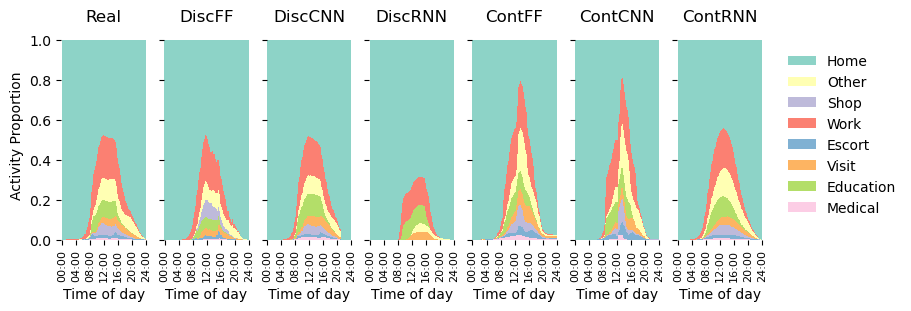

In [12]:
fig = frequency_plots(
    target_schedules,
    schedules,
    color=cmap,
    figsize=(9, 3),
    observed_title="Real",
    interval=240,
)

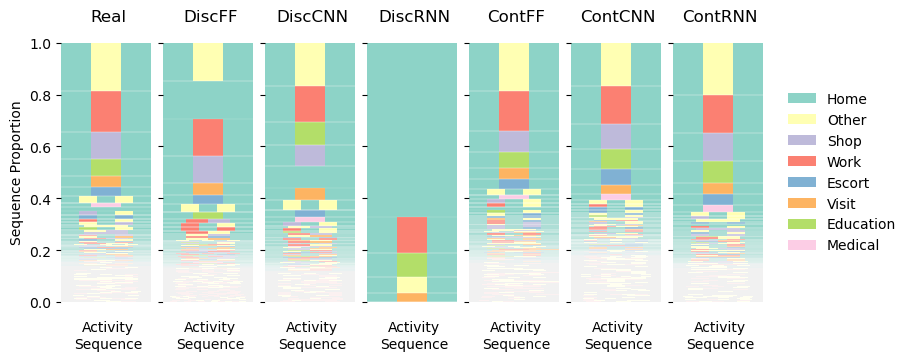

In [13]:
fig = sequence_prob_plot(
    target_schedules,
    schedules,
    cmap=cmap,
    figsize=(9, 3.5),
    observed_title="Real",
)

In [14]:
best = {k: v for k, v in schedules.items() if k in ["DiscCNN", "ContRNN"]}

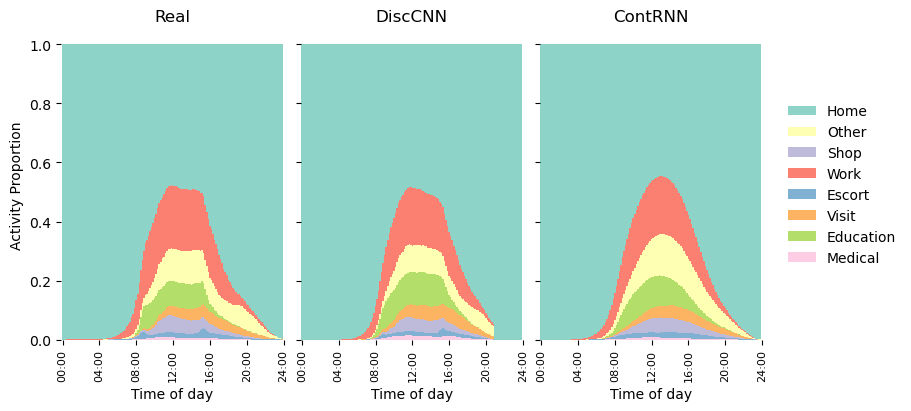

In [15]:
fig = frequency_plots(
    target_schedules,
    best,
    color=cmap,
    figsize=(9, 4),
    observed_title="Real",
    interval=120,
)

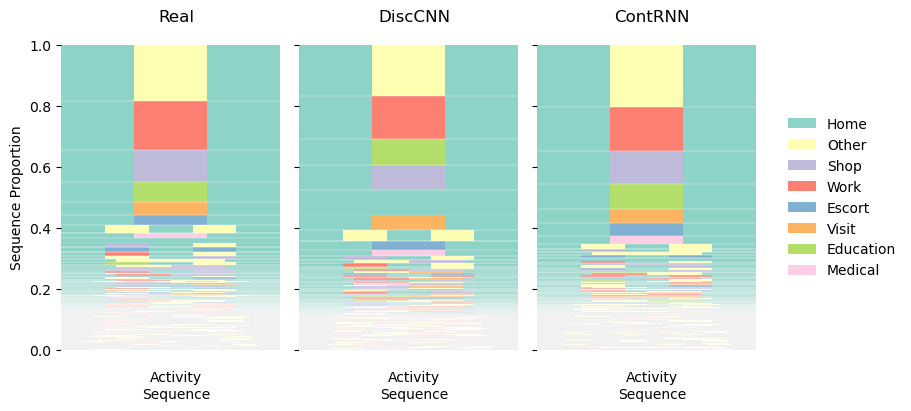

In [16]:
fig = sequence_prob_plot(
    target_schedules, best, cmap=cmap, figsize=(9, 4), observed_title="Real"
)

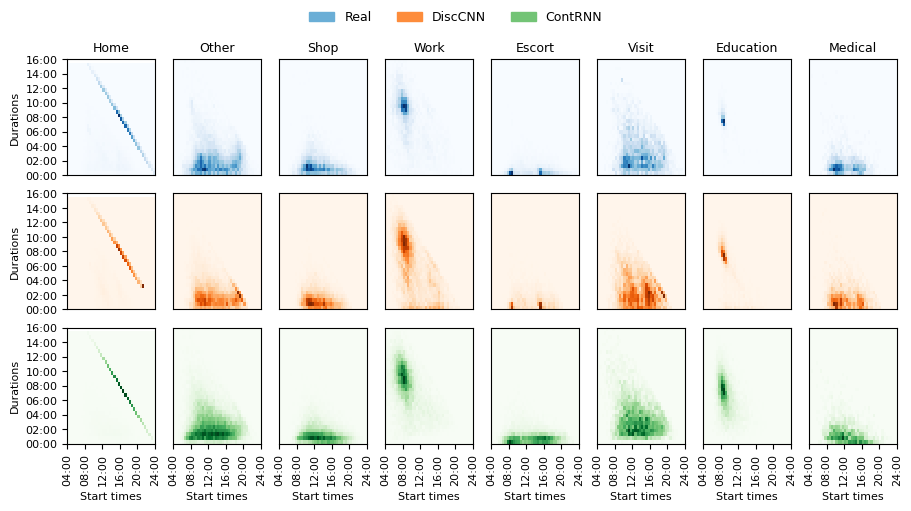

In [17]:
fig = joint_time_distributions_plot(
    target_schedules,
    best,
    figsize=(9, 5),
    observed_title="Real",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Oranges",
        4: "Oranges",
        5: "Oranges",
        6: "Oranges",
    },
)

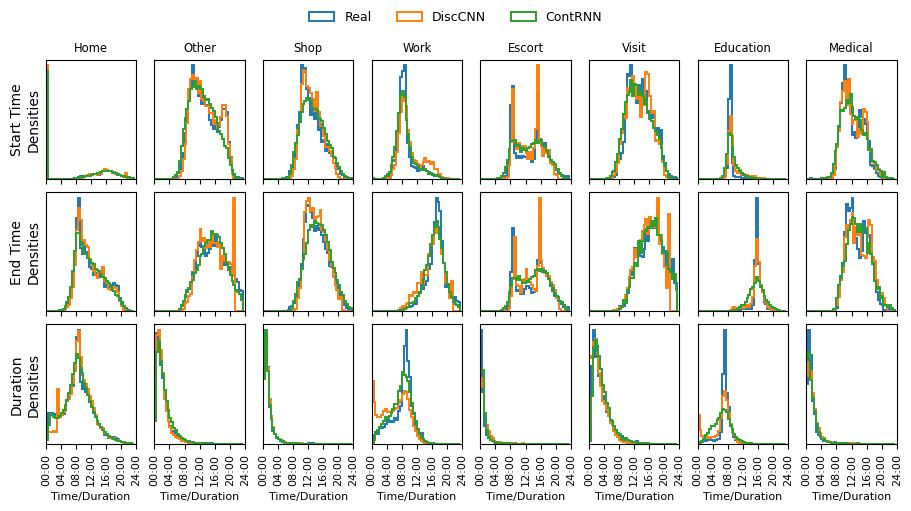

In [18]:
fig = times_distributions_plot(
    target_schedules, best, observed_title="Real", figsize=(9, 5)
)

In [19]:
import random

from pam.core import Household, Person
from pam.plot.plans import plot_household

from caveat.data.utils import trace_to_pam


def stretch(schedules):
    return schedules.groupby(schedules.pid).apply(stretcher)


def stretcher(schedule):
    duration = schedule.duration.sum()
    if duration != 1440:
        a = 1440 / duration
        schedule.duration = (schedule.duration * a).astype(int)
        accumulated = list(schedule.duration.cumsum())
        schedule.start = [0] + accumulated[:-1]
        schedule.end = accumulated
    return schedule


def trim(schedules):
    schedules[schedules.end > 1440] = 1440
    schedules[schedules.start > 1440] = 1440
    schedules.duration = schedules.end - schedules.start
    schedules = schedules[schedules.duration > 0]
    return schedules


def pad(schedules):
    return (
        schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
    )


def padder(schedule):
    if schedule.end.iloc[-1] < 1440 and schedule.act.iloc[-1] != "home":
        pid = schedule.pid.iloc[0]
        schedule = pd.concat(
            [
                schedule,
                DataFrame(
                    {
                        "pid": pid,
                        "start": schedule.end.iloc[-1],
                        "end": 1440,
                        "duration": 1440 - schedule.end.iloc[-1],
                        "act": "home",
                    },
                    index=[0],
                ),
            ]
        )
    elif schedule.end.iloc[-1] < 1440:
        schedule.end.iloc[-1] = 1440
        schedule.duration.iloc[-1] = 1440 - schedule.start.iloc[-1]
    return schedule


def plot_schedules(schedules, **kwargs):

    cmap = {
        "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
        "other": (1.0, 1.0, 0.7019607843137254),
        "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
        "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
        "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
        "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
        "education": (
            0.7019607843137254,
            0.8705882352941177,
            0.4117647058823529,
        ),
        "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
        "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
    }
    cmap = {n.title(): c for n, c in cmap.items()}

    hh = Household("")

    pids = schedules.pid
    selected = random.sample(list(pids), 5)
    for i, pid in enumerate(selected):
        person = Person(pid)
        plan = schedules[schedules.pid == pid]
        plan = trim(stretch(pad(plan)))[["act", "start", "end", "duration"]]
        mapping = {a: a for a in plan.act}

        trace = [
            (row.act, row.start, row.end, row.duration)
            for i, row in plan.iterrows()
        ]
        plan = trace_to_pam(trace, mapping)

        person = Person(i)
        person.plan = plan
        hh.add(person)

    plot_household(hh, cmap=cmap, width=25)

/tmp/ipykernel_385274/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_385274/1738895634.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_385274/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping 

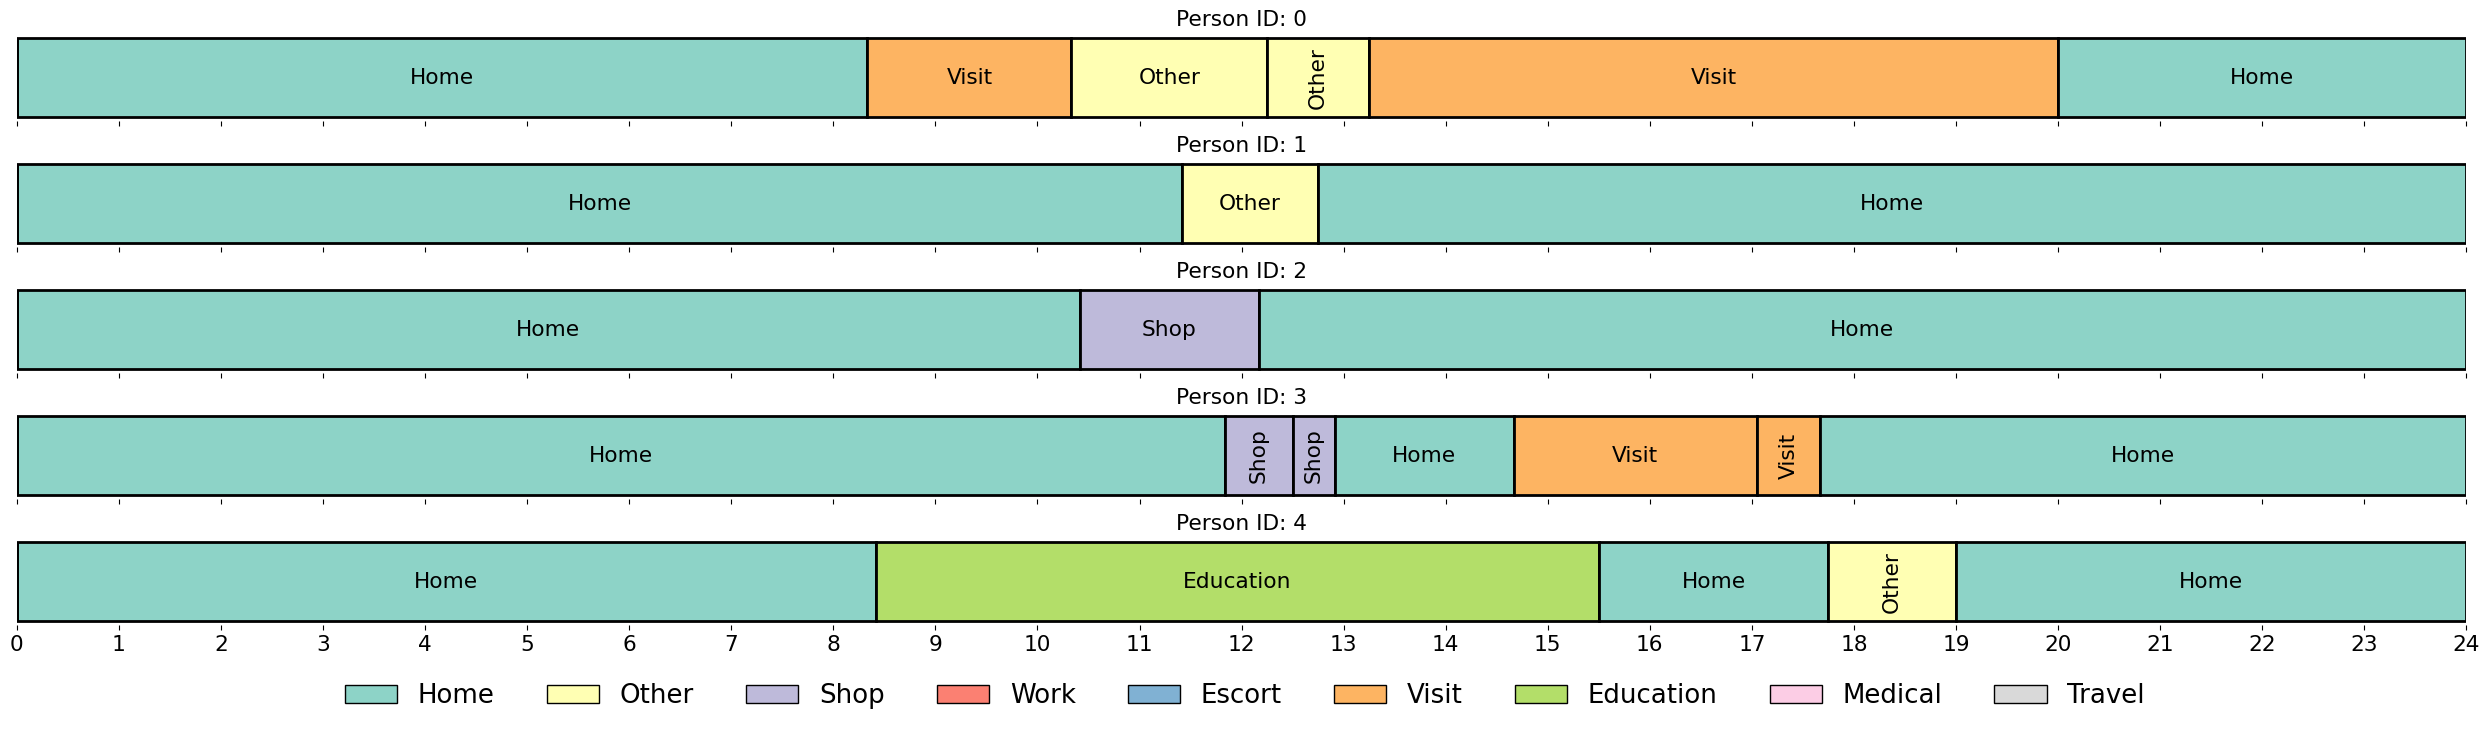

In [20]:
plot_schedules(target_schedules)

/tmp/ipykernel_385274/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_385274/1738895634.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_385274/1738895634.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping 

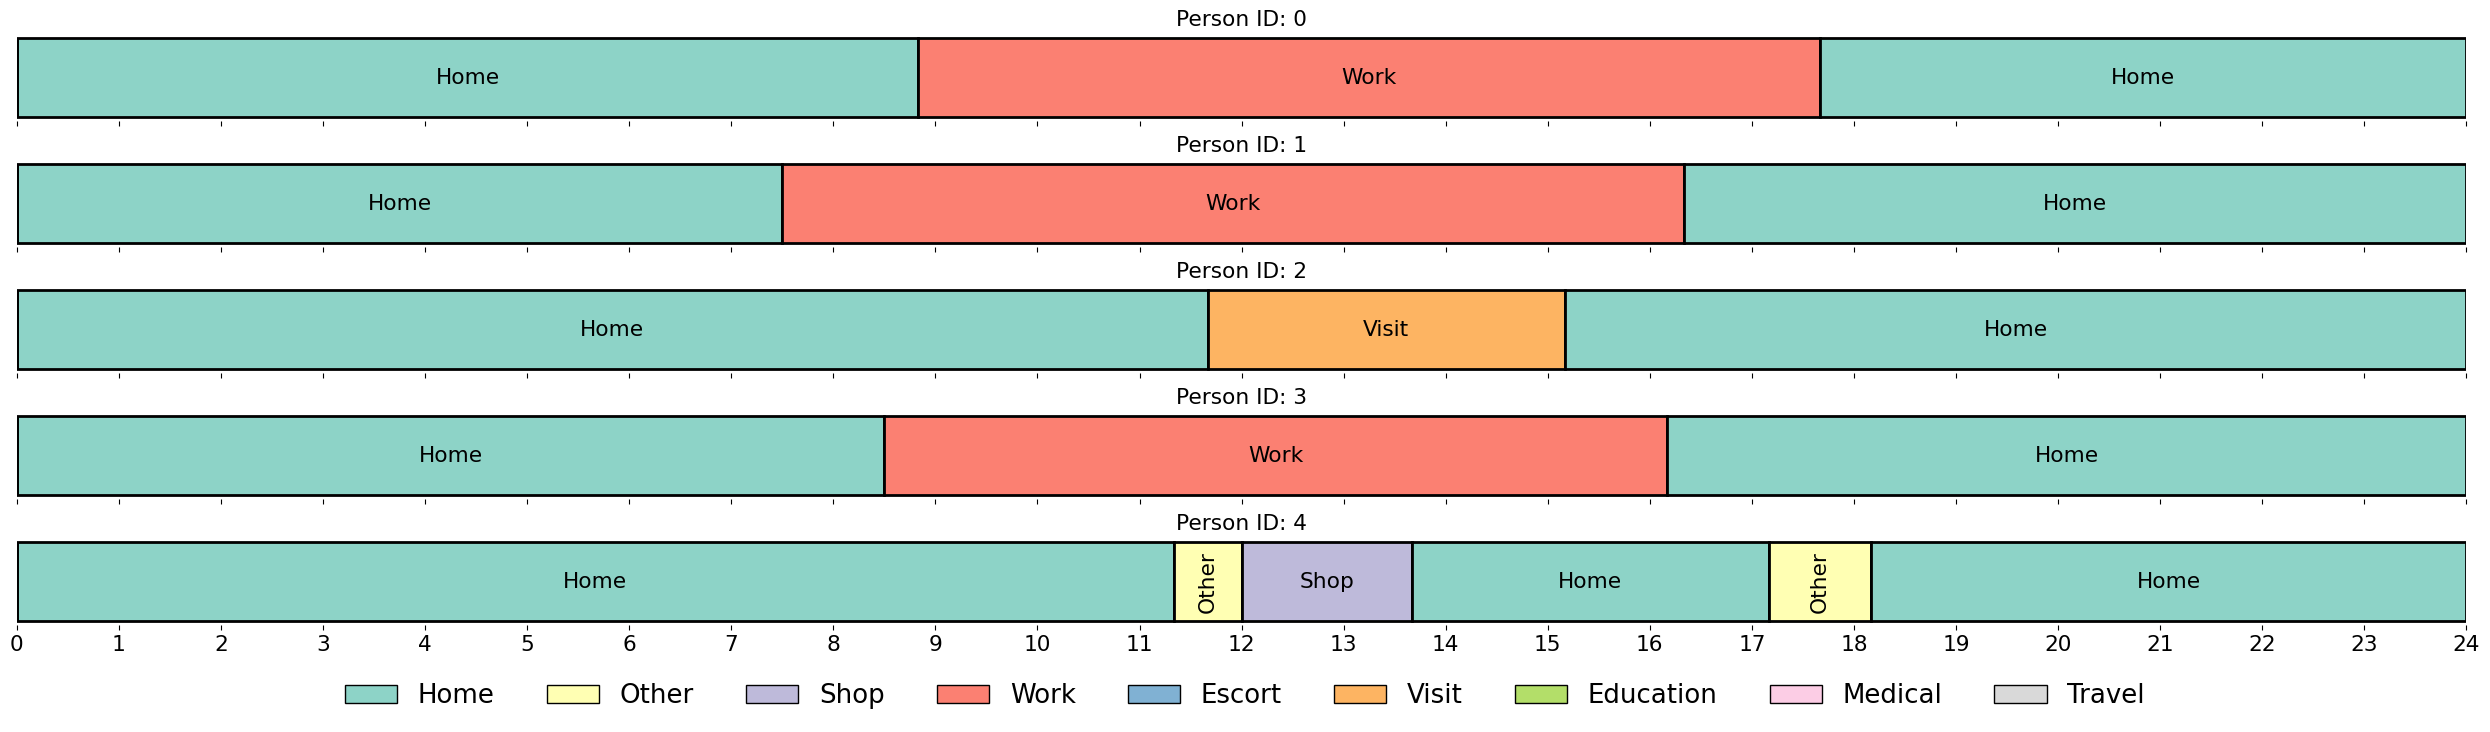

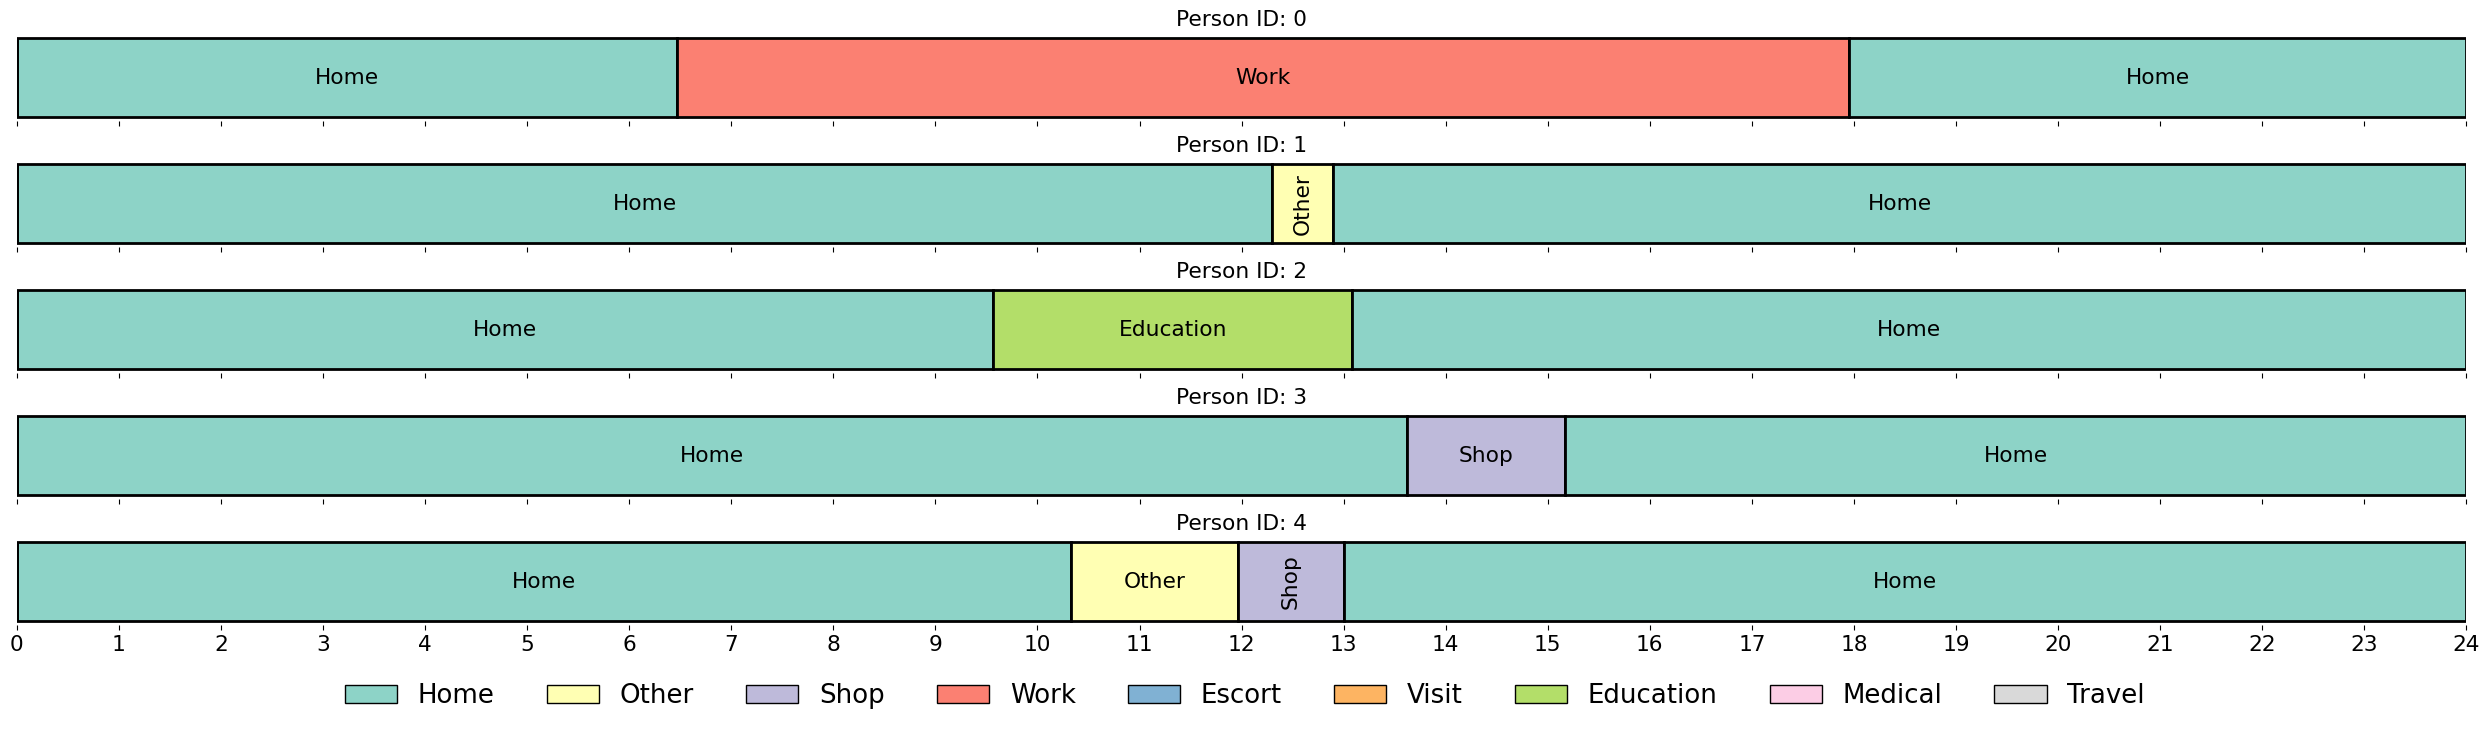

In [21]:
for n, p in batch_paths.items():
    if n in ["DiscCNN", "ContRNN"]:
        examples = pd.read_csv(next(find_nth(p))[1] / "synthetic_schedules.csv")
        plot_schedules(examples)

In [22]:
# 2019 t0 2020 scenario
covid_scenario_paths = {
    # "ContRNN": Path("../logs/vae_paper/ContRNN"),
    # "ContRNN_frozen": Path("../logs/vae_paper/ContRNN_Covid_frozen"),
    # "ContRNN_unfrozen": Path("../logs/vae_paper/ContRNN_Covid_retuned"),
    "syn2019": Path("../logs/vae_paper/ContRNN_2019"),
    "syn2020": Path("../logs/vae_paper/ContRNN_Covid_retuned"),
}
target_2019_schedules = pd.read_csv("../tmp/nts_schedules_2019_50.csv")
target_2020_schedules = pd.read_csv("../tmp/nts_schedules_2020.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

covid_scenario = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in covid_scenario_paths.items()
}

target_2019_schedules.pid.nunique(), target_2020_schedules.pid.nunique()

(23452, 23452)

In [23]:
# comapare real 2019 and 2020
from caveat.evaluate.evaluate import evaluate

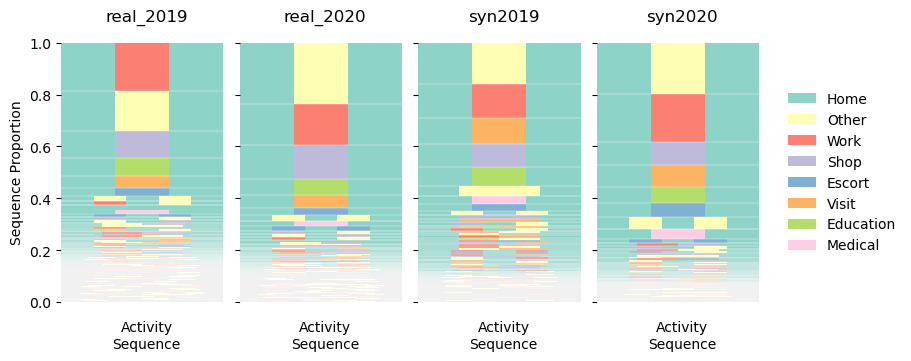

In [24]:
fig = sequence_prob_plot(
    target_2019_schedules,
    {
        "real_2020": target_2020_schedules,
        "syn2019": covid_scenario["syn2019"],
        "syn2020": covid_scenario["syn2020"],
    },
    cmap=cmap,
    figsize=(9, 3.5),
    observed_title="real_2019",
)

In [25]:
reports_base_2019 = evaluate(
    {
        "real2020": target_2020_schedules,
        "syn2019": covid_scenario["syn2019"],
        "syn2020": covid_scenario["syn2020"],
    },
    target_2019_schedules,
    report_stats=False,
)
reports_base_2020 = evaluate(
    {
        "real2019": target_2019_schedules,
        "syn2019": covid_scenario["syn2019"],
        "syn2020": covid_scenario["syn2020"],
    },
    target_2020_schedules,
    report_stats=False,
)

In [26]:
scenario_summary = reports_base_2019["feature_descriptions"].loc[
    ["participations", "transitions", "timing"], ["observed", "real2020"]
]
scenario_summary.rename(
    columns={"observed": "Real 2019", "real2020": "Real 2020"}, inplace=True
)

scenario_summary["Real Diff"] = (
    scenario_summary["Real 2020"] - scenario_summary["Real 2019"]
)
# scenario_summary["Real EMD"] = reports_base_2019["feature_distances"].loc[
#     ["participations", "transitions", "timing"], "real2020"
# ]

dist_dist, dist_std, dist_desc = distribution_distances(covid_scenario_paths)
scenario_summary["Syn 2019"] = dist_desc.loc[
    ["participations", "transitions", "timing"], "syn2019"
]
scenario_summary["Syn 2020"] = dist_desc.loc[
    ["participations", "transitions", "timing"], "syn2020"
]

scenario_summary["Syn Diff"] = (
    scenario_summary["Syn 2020"] - scenario_summary["Syn 2019"]
)

scenario_summary.index = scenario_summary.index.droplevel(level=0)

print(scenario_summary.to_latex(float_format="{:.3f}".format))

\begin{tabular}{lrrrrrr}
\toprule
 & Real 2019 & Real 2020 & Real Diff & Syn 2019 & Syn 2020 & Syn Diff \\
feature &  &  &  &  &  &  \\
\midrule
lengths & 3.887 & 3.717 & -0.171 & 3.700 & 3.527 & -0.173 \\
pair participation rate & 0.041 & 0.039 & -0.002 & 0.037 & 0.036 & -0.002 \\
participation rate & 0.486 & 0.465 & -0.021 & 0.462 & 0.441 & -0.022 \\
2-gram & 0.049 & 0.046 & -0.002 & 0.049 & 0.050 & 0.001 \\
3-gram & 0.006 & 0.006 & 0.000 & 0.007 & 0.008 & 0.001 \\
4-gram & 0.002 & 0.003 & 0.000 & 0.003 & 0.005 & 0.001 \\
durations & 0.257 & 0.269 & 0.012 & 0.270 & 0.284 & 0.013 \\
joint-durations & 0.434 & 0.445 & 0.011 & 0.460 & 0.470 & 0.010 \\
start times & 0.428 & 0.412 & -0.016 & 0.427 & 0.413 & -0.015 \\
start-durations & 0.690 & 0.686 & -0.004 & 0.700 & 0.698 & -0.001 \\
\bottomrule
\end{tabular}



In [27]:
scenario_summary = reports_base_2019["descriptions"].loc[
    ["participations"], ["observed", "real2020"]
]
scenario_summary.rename(
    columns={"observed": "Real 2019", "real2020": "Real 2020"}, inplace=True
)

scenario_summary["Real Diff"] = (
    scenario_summary["Real 2020"] - scenario_summary["Real 2019"]
)

scenario_summary["Syn 2019"] = get_models_description(
    covid_scenario_paths, ["syn2019", "syn2020"], 20
).loc[["participations"], [("syn2019", "description")]]

scenario_summary["Syn 2020"] = get_models_description(
    covid_scenario_paths, ["syn2019", "syn2020"], 20
).loc[["participations"], [("syn2020", "description")]]

scenario_summary["Syn Diff"] = (
    scenario_summary["Syn 2020"] - scenario_summary["Syn 2019"]
)

scenario_summary.index = scenario_summary.index.droplevel(level=0)
scenario_summary = scenario_summary.loc["participation rate"]
print(scenario_summary.to_latex(float_format="{:.3f}".format))

\begin{tabular}{lrrrrrr}
\toprule
 & Real 2019 & Real 2020 & Real Diff & Syn 2019 & Syn 2020 & Syn Diff \\
segment &  &  &  &  &  &  \\
\midrule
education & 0.095 & 0.077 & -0.017 & 0.107 & 0.073 & -0.034 \\
escort & 0.251 & 0.217 & -0.034 & 0.166 & 0.164 & -0.002 \\
home & 2.294 & 2.250 & -0.044 & 2.218 & 2.176 & -0.042 \\
medical & 0.039 & 0.041 & 0.002 & 0.048 & 0.041 & -0.007 \\
other & 0.468 & 0.483 & 0.015 & 0.439 & 0.390 & -0.049 \\
shop & 0.293 & 0.284 & -0.008 & 0.274 & 0.275 & 0.001 \\
visit & 0.139 & 0.123 & -0.017 & 0.176 & 0.160 & -0.015 \\
work & 0.310 & 0.242 & -0.068 & 0.272 & 0.247 & -0.025 \\
\bottomrule
\end{tabular}



In [28]:
dist_dist, dist_std, dist_desc = distribution_distances(covid_scenario_paths)
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))
print(dist_desc.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))
display(dist_dist)
display(dist_desc)

\begin{tabular}{lrr}
\toprule
 & syn2019 & syn2020 \\
 & mean & mean \\
feature &  &  \\
\midrule
conservatism & 0.005 & 0.006 \\
homogeneity & 0.006 & 0.018 \\
consecutive & 0.026 & 0.015 \\
invalid & 0.026 & 0.016 \\
not home based & 0.000 & 0.001 \\
agg. frequency & 0.010 & 0.009 \\
lengths & 0.290 & 0.230 \\
pair participation rate & 0.006 & 0.005 \\
participation rate & 0.049 & 0.048 \\
2-gram & 0.012 & 0.013 \\
3-gram & 0.003 & 0.004 \\
4-gram & 0.003 & 0.004 \\
durations & 0.024 & 0.028 \\
joint-durations & 0.059 & 0.067 \\
start times & 0.020 & 0.026 \\
start-durations & 0.044 & 0.050 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrr}
\toprule
 & syn2019 & syn2020 \\
 & mean & mean \\
feature &  &  \\
\midrule
diversity & 0.994 & 0.982 \\
novelty & 0.995 & 0.994 \\
consecutive & 0.026 & 0.015 \\
invalid & 0.026 & 0.016 \\
not home based & 0.000 & 0.001 \\
agg. frequency & 0.630 & 0.707 \\
lengths & 3.700 & 3.527 \\
pair participation rate & 0.037 & 0.036 \\
participation rate &

syn2019   syn2020
                                            mean      mean
domain         feature                                    
creativity     conservatism             0.004943  0.006300
               homogeneity              0.006260  0.018105
sample quality consecutive              0.026123  0.015221
               invalid                  0.026175  0.015729
               not home based           0.000052  0.000507
aggregate      agg. frequency           0.010258  0.009484
participations lengths                  0.289562  0.229908
               pair participation rate  0.005528  0.005197
               participation rate       0.048847  0.047592
transitions    2-gram                   0.011707  0.013181
               3-gram                   0.003045  0.003507
               4-gram                   0.002527  0.003727
timing         durations                0.023912  0.028328
               joint-durations          0.059243  0.066645
               start times              0.019521  0.025800
               start-durations          0.044367  0.050197

syn2019   syn2020
                                            mean      mean
domain         feature                                    
creativity     diversity                0.993740  0.981895
               novelty                  0.995057  0.993700
sample quality consecutive              0.026123  0.015221
               invalid                  0.026175  0.015729
               not home based           0.000052  0.000507
aggregate      agg. frequency           0.629720  0.707098
participations lengths                  3.699787  3.526531
               pair participation rate  0.037321  0.035663
               participation rate       0.462473  0.440816
transitions    2-gram                   0.048863  0.049984
               3-gram                   0.007459  0.008178
               4-gram                   0.003314  0.004584
timing         durations                0.270368  0.283569
               joint-durations          0.460310  0.470408
               start times              0.427245  0.412701
               start-durations          0.699639  0.698359

In [29]:
reports_base_2019["distances"].loc[("participations", "lengths")]

/tmp/ipykernel_385274/1981961630.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  reports_base_2019["distances"].loc[("participations", "lengths")]


,observed__weight,observed,real2020,real2020__weight,syn2019,syn2019__weight,syn2020,syn2020__weight,unit
segment,,,,,,,,,
sequence lengths,23452.0,3.887387,0.203096,23452.0,0.2894,23452.0,0.419538,23452.0,EMD


In [30]:
reports_base_2020["distances"].loc[("participations", "lengths")]

/tmp/ipykernel_385274/2841695820.py:1: PerformanceWarning: indexing past lexsort depth may impact performance.
  reports_base_2020["distances"].loc[("participations", "lengths")]


,observed__weight,observed,real2019,real2019__weight,syn2019,syn2019__weight,syn2020,syn2020__weight,unit
segment,,,,,,,,,
sequence lengths,23452.0,3.716613,0.203096,23452.0,0.23418,23452.0,0.21738,23452.0,EMD


In [31]:
# COVID SCENARIO
covid_scenario_paths = {
    # "ContRNN": Path("../logs/vae_paper/ContRNN"),
    # "ContRNN_frozen": Path("../logs/vae_paper/ContRNN_Covid_frozen"),
    # "ContRNN_unfrozen": Path("../logs/vae_paper/ContRNN_Covid_retuned"),
    "ContRNN_mid": Path("../logs/vae_paper/ContRNN_Covid_retuned")
}
covid_target_schedules = pd.read_csv("../tmp/nts_schedules_2020.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

covid_scenario = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in covid_scenario_paths.items()
}

covid_target_schedules.pid.nunique()

23452

In [32]:
covid_dist, covid_var = domain_distances(covid_scenario_paths, suffix="")
covid_dist_dist, covid_dist_std, covid_dist_desc = distribution_distances(
    covid_scenario_paths
)

print(covid_dist[::-1].to_latex(float_format="{:.3f}".format))
print(
    covid_dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format)
)


display(covid_dist_desc)

\begin{tabular}{lr}
\toprule
 & dist \\
domain &  \\
\midrule
aggregate & 0.009 \\
count & 0.000 \\
creativity & 0.012 \\
participations & 0.094 \\
sample quality & 0.016 \\
timing & 0.043 \\
transitions & 0.007 \\
\bottomrule
\end{tabular}

\begin{tabular}{lr}
\toprule
 & ContRNN_mid \\
 & mean \\
feature &  \\
\midrule
conservatism & 0.006 \\
homogeneity & 0.018 \\
consecutive & 0.015 \\
invalid & 0.016 \\
not home based & 0.001 \\
agg. frequency & 0.009 \\
lengths & 0.230 \\
pair participation rate & 0.005 \\
participation rate & 0.048 \\
2-gram & 0.013 \\
3-gram & 0.004 \\
4-gram & 0.004 \\
durations & 0.028 \\
joint-durations & 0.067 \\
start times & 0.026 \\
start-durations & 0.050 \\
\bottomrule
\end{tabular}



ContRNN_mid
                                              mean
domain         feature                            
creativity     diversity                  0.981895
               novelty                    0.993700
sample quality consecutive                0.015221
               invalid                    0.015729
               not home based             0.000507
aggregate      agg. frequency             0.707098
participations lengths                    3.526531
               pair participation rate    0.035663
               participation rate         0.440816
transitions    2-gram                     0.049984
               3-gram                     0.008178
               4-gram                     0.004584
timing         durations                  0.283569
               joint-durations            0.470408
               start times                0.412701
               start-durations            0.698359

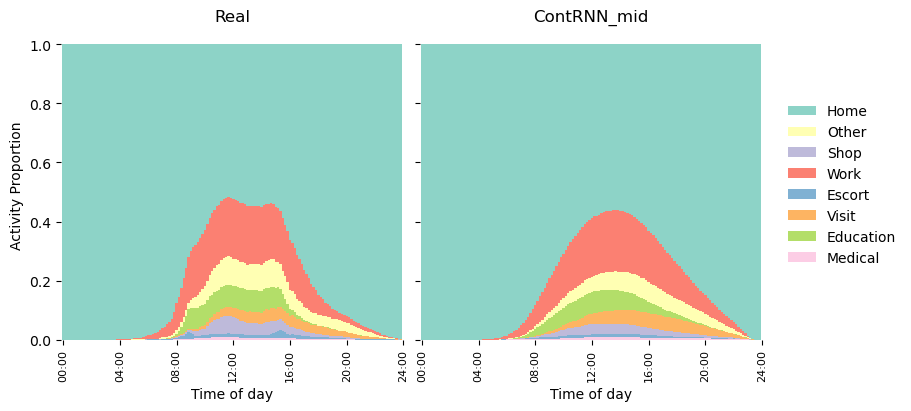

In [33]:
fig = frequency_plots(
    covid_target_schedules,
    covid_scenario,
    color=cmap,
    figsize=(9, 4),
    observed_title="Real",
    interval=240,
)

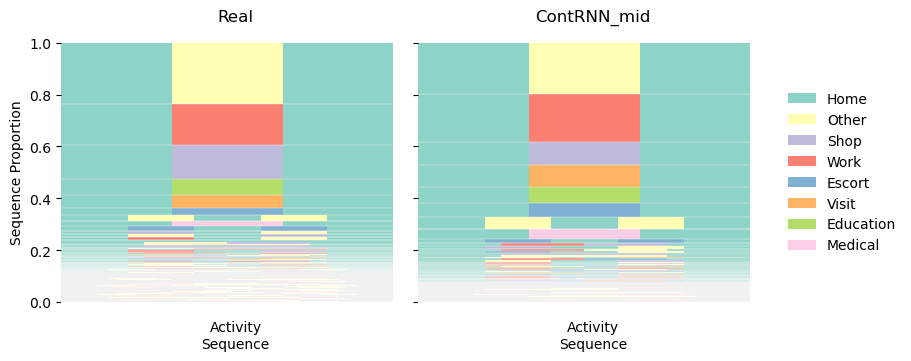

In [34]:
fig = sequence_prob_plot(
    covid_target_schedules,
    covid_scenario,
    cmap=cmap,
    figsize=(9, 3.5),
    observed_title="Real",
)

In [35]:
# SIZE SCENARIOS
sample_scenario_paths = {
    "100%": Path("../logs/vae_paper/ContRNN"),
    "50%": Path("../logs/vae_paper/ContRNN_50"),
    "25%": Path("../logs/vae_paper/ContRNN_25"),
    "12%": Path("../logs/vae_paper/ContRNN_12"),
}
sample_target_schedules = pd.read_csv("../tmp/nts_schedules_2023.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

sample_scenarios = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in sample_scenario_paths.items()
}

sample_dist, sample_var = domain_distances(sample_scenario_paths, suffix="")
sample_dist_dist, sample_dist_std, sample_dist_desc = distribution_distances(
    sample_scenario_paths
)

print(sample_dist[::-1].to_latex(float_format="{:.3f}".format))
print(
    sample_dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format)
)

display(sample_dist)
display(sample_dist_dist)
display(sample_dist_desc)

\begin{tabular}{lrrrr}
\toprule
 & dist & dist & dist & dist \\
domain &  &  &  &  \\
\midrule
aggregate & 0.009 & 0.009 & 0.013 & 0.029 \\
count & 0.000 & 0.000 & 0.000 & 0.000 \\
creativity & 0.017 & 0.008 & 0.046 & 0.037 \\
participations & 0.064 & 0.085 & 0.147 & 0.214 \\
sample quality & 0.018 & 0.030 & 0.071 & 0.279 \\
timing & 0.025 & 0.030 & 0.060 & 0.089 \\
transitions & 0.004 & 0.006 & 0.036 & 0.055 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrr}
\toprule
 & 100% & 50% & 25% & 12% \\
 & mean & mean & mean & mean \\
feature &  &  &  &  \\
\midrule
conservatism & 0.012 & 0.007 & 0.006 & 0.004 \\
homogeneity & 0.022 & 0.009 & 0.086 & 0.070 \\
consecutive & 0.018 & 0.029 & 0.069 & 0.211 \\
invalid & 0.018 & 0.030 & 0.071 & 0.279 \\
not home based & 0.001 & 0.001 & 0.003 & 0.121 \\
agg. frequency & 0.009 & 0.009 & 0.013 & 0.029 \\
lengths & 0.154 & 0.212 & 0.316 & 0.453 \\
pair participation rate & 0.004 & 0.004 & 0.011 & 0.017 \\
participation rate & 0.033 & 0.038 & 0.112 & 

,100%,50%,25%,12%
,dist,dist,dist,dist
domain,,,,
aggregate,0.008588,0.008691,0.012902,0.028560
count,0.000000,0.000000,0.000000,0.000000
creativity,0.017146,0.008266,0.046436,0.037006
participations,0.063894,0.084954,0.146577,0.214287
sample quality,0.018193,0.029965,0.071409,0.279449
timing,0.025205,0.030191,0.060018,0.089031
transitions,0.003823,0.006350,0.035999,0.055154


100%       50%       25%       12%
                                            mean      mean      mean      mean
domain         feature                                                        
creativity     conservatism             0.012104  0.007199  0.006498  0.004251
               homogeneity              0.022188  0.009333  0.086373  0.069760
sample quality consecutive              0.017694  0.028579  0.069017  0.211016
               invalid                  0.018193  0.029965  0.071409  0.279449
               not home based           0.000507  0.001406  0.002862  0.121132
aggregate      agg. frequency           0.008588  0.008691  0.012902  0.028560
participations lengths                  0.154408  0.212147  0.315827  0.453333
               pair participation rate  0.003939  0.004239  0.011410  0.017272
               participation rate       0.033335  0.038477  0.112493  0.172257
transitions    2-gram                   0.008133  0.011372  0.062572  0.102399
               3-gram                   0.001924  0.004078  0.022489  0.032858
               4-gram                   0.001412  0.003599  0.022936  0.030206
timing         durations                0.016155  0.019791  0.041238  0.053412
               joint-durations          0.037689  0.048768  0.095465  0.124245
               start times              0.015942  0.016755  0.033647  0.062794
               start-durations          0.031032  0.035448  0.069722  0.115671

100%       50%       25%       12%
                                            mean      mean      mean      mean
domain         feature                                                        
creativity     diversity                0.977812  0.990667  0.913627  0.930240
               novelty                  0.987896  0.992801  0.993502  0.995749
sample quality consecutive              0.017694  0.028579  0.069017  0.211016
               invalid                  0.018193  0.029965  0.071409  0.279449
               not home based           0.000507  0.001406  0.002862  0.121132
aggregate      agg. frequency           0.631839  0.634859  0.654882  0.596795
participations lengths                  3.840142  3.778220  3.684800  3.530933
               pair participation rate  0.039990  0.040800  0.061283  0.049368
               participation rate       0.480018  0.472277  0.578687  0.538838
transitions    2-gram                   0.048130  0.057524  0.120251  0.143089
               3-gram                   0.006278  0.010610  0.035255  0.044682
               4-gram                   0.002477  0.005256  0.025549  0.033136
timing         durations                0.260462  0.264701  0.271515  0.284082
               joint-durations          0.436733  0.447815  0.461376  0.493108
               start times              0.429090  0.428518  0.417413  0.414895
               start-durations          0.691530  0.695216  0.690944  0.701109

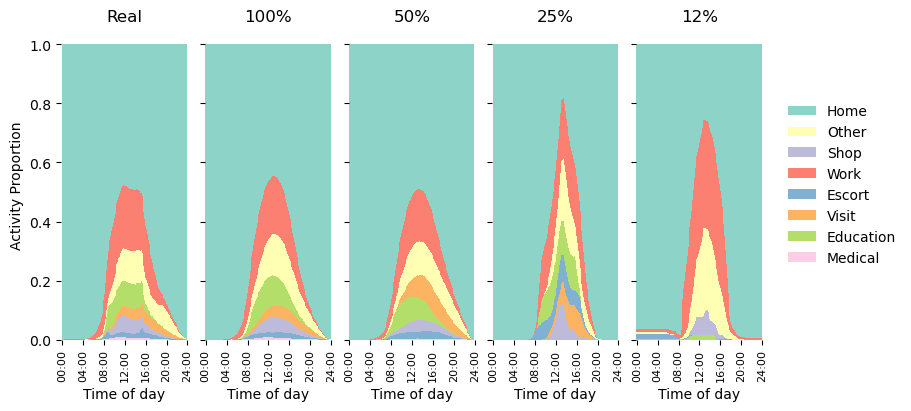

In [36]:
fig = frequency_plots(
    sample_target_schedules,
    sample_scenarios,
    color=cmap,
    figsize=(9, 4),
    observed_title="Real",
    interval=240,
)

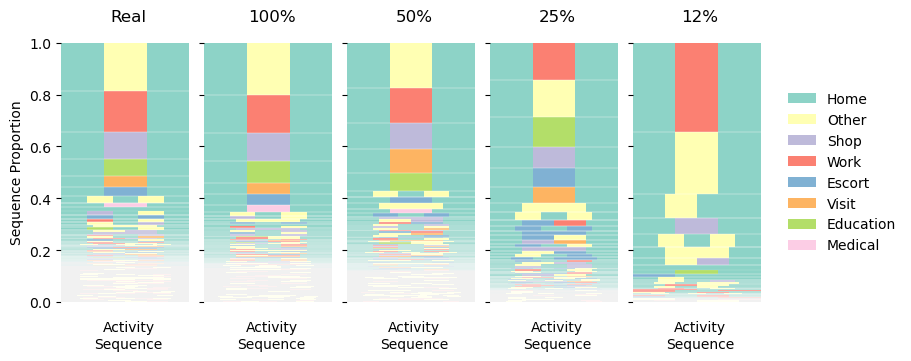

In [37]:
fig = sequence_prob_plot(
    sample_target_schedules,
    sample_scenarios,
    cmap=cmap,
    figsize=(9, 3.5),
    observed_title="Real",
)

In [38]:
# SIZE SCENARIOS
sample_scenario_paths_small = {
    "100%": Path("../logs/vae_paper/ContRNN"),
    "50%": Path("../logs/vae_paper/ContRNN_50_small"),
    "25%": Path("../logs/vae_paper/ContRNN_25_small"),
    "12%": Path("../logs/vae_paper/ContRNN_12_small"),
}
sample_target_schedules = pd.read_csv("../tmp/nts_schedules_2023.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

sample_scenarios_small = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in sample_scenario_paths_small.items()
}

sample_dist, sample_var = domain_distances(
    sample_scenario_paths_small, suffix=""
)
sample_dist_dist, sample_dist_std, sample_dist_desc = distribution_distances(
    sample_scenario_paths_small
)

print(sample_dist[::-1].to_latex(float_format="{:.3f}".format))
print(
    sample_dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format)
)

display(sample_dist)
display(sample_dist_dist)
display(sample_dist_desc)

\begin{tabular}{lrrrr}
\toprule
 & dist & dist & dist & dist \\
domain &  &  &  &  \\
\midrule
aggregate & 0.009 & 0.009 & 0.013 & 0.039 \\
count & 0.000 & 0.000 & 0.000 & 0.000 \\
creativity & 0.017 & 0.006 & 0.009 & 0.097 \\
participations & 0.064 & 0.098 & 0.186 & 0.449 \\
sample quality & 0.018 & 0.019 & 0.055 & 0.144 \\
timing & 0.025 & 0.035 & 0.057 & 0.121 \\
transitions & 0.004 & 0.005 & 0.012 & 0.053 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrr}
\toprule
 & 100% & 50% & 25% & 12% \\
 & mean & mean & mean & mean \\
feature &  &  &  &  \\
\midrule
conservatism & 0.012 & 0.006 & 0.003 & 0.003 \\
homogeneity & 0.022 & 0.007 & 0.015 & 0.190 \\
consecutive & 0.018 & 0.018 & 0.029 & 0.029 \\
invalid & 0.018 & 0.019 & 0.055 & 0.144 \\
not home based & 0.001 & 0.000 & 0.031 & 0.117 \\
agg. frequency & 0.009 & 0.009 & 0.013 & 0.039 \\
lengths & 0.154 & 0.239 & 0.461 & 1.130 \\
pair participation rate & 0.004 & 0.005 & 0.008 & 0.022 \\
participation rate & 0.033 & 0.050 & 0.089 & 

,100%,50%,25%,12%
,dist,dist,dist,dist
domain,,,,
aggregate,0.008588,0.009369,0.013160,0.039149
count,0.000000,0.000000,0.000000,0.000000
creativity,0.017146,0.006373,0.009285,0.096685
participations,0.063894,0.097876,0.186083,0.449049
sample quality,0.018193,0.018518,0.055169,0.144308
timing,0.025205,0.034810,0.056783,0.121175
transitions,0.003823,0.005226,0.011580,0.053002


100%       50%       25%       12%
                                            mean      mean      mean      mean
domain         feature                                                        
creativity     conservatism             0.012104  0.006054  0.003383  0.003397
               homogeneity              0.022188  0.006693  0.015187  0.189973
sample quality consecutive              0.017694  0.018417  0.029116  0.028606
               invalid                  0.018193  0.018518  0.055169  0.144308
               not home based           0.000507  0.000134  0.030859  0.117345
aggregate      agg. frequency           0.008588  0.009369  0.013160  0.039149
participations lengths                  0.154408  0.238593  0.461253  1.129547
               pair participation rate  0.003939  0.005487  0.008317  0.022389
               participation rate       0.033335  0.049548  0.088679  0.195212
transitions    2-gram                   0.008133  0.011159  0.022629  0.080994
               3-gram                   0.001924  0.002578  0.006209  0.032473
               4-gram                   0.001412  0.001940  0.005903  0.045539
timing         durations                0.016155  0.022212  0.035940  0.084190
               joint-durations          0.037689  0.054436  0.088140  0.169196
               start times              0.015942  0.020541  0.032242  0.061487
               start-durations          0.031032  0.042050  0.070808  0.169829

100%       50%       25%       12%
                                            mean      mean      mean      mean
domain         feature                                                        
creativity     diversity                0.977812  0.993307  0.984813  0.810027
               novelty                  0.987896  0.993946  0.996617  0.996603
sample quality consecutive              0.017694  0.018417  0.029116  0.028606
               invalid                  0.018193  0.018518  0.055169  0.144308
               not home based           0.000507  0.000134  0.030859  0.117345
aggregate      agg. frequency           0.631839  0.653538  0.618095  0.698267
participations lengths                  3.840142  3.736347  3.504147  2.779520
               pair participation rate  0.039990  0.038385  0.037621  0.028313
               participation rate       0.480018  0.467043  0.449836  0.386880
transitions    2-gram                   0.048130  0.045884  0.055106  0.099012
               3-gram                   0.006278  0.006334  0.009909  0.033476
               4-gram                   0.002477  0.002659  0.005497  0.037068
timing         durations                0.260462  0.267689  0.285631  0.360524
               joint-durations          0.436733  0.448609  0.488292  0.554503
               start times              0.429090  0.431011  0.401225  0.355535
               start-durations          0.691530  0.700718  0.688951  0.718796

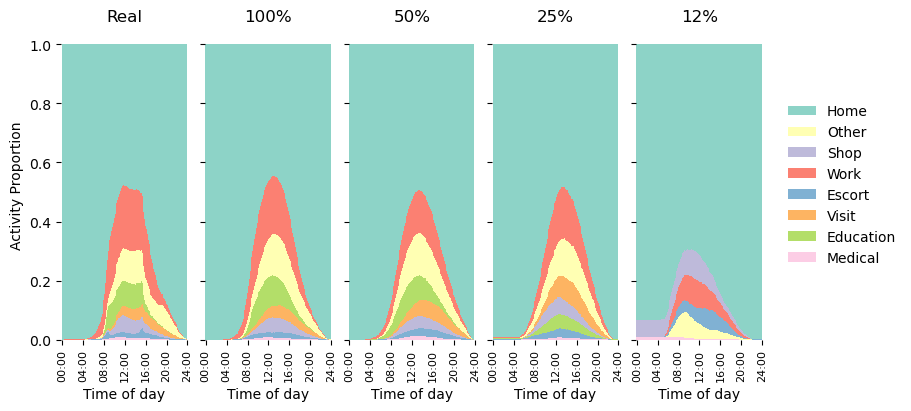

In [39]:
fig = frequency_plots(
    sample_target_schedules,
    sample_scenarios_small,
    color=cmap,
    figsize=(9, 4),
    observed_title="Real",
    interval=240,
)

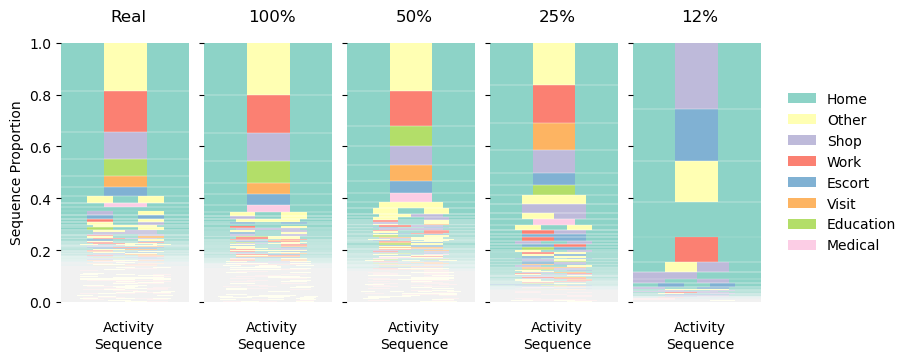

In [40]:
fig = sequence_prob_plot(
    sample_target_schedules,
    sample_scenarios_small,
    cmap=cmap,
    figsize=(9, 3.5),
    observed_title="Real",
)